In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"aadhilshahulhameed","key":"0fbd770f713bd267a5dc402dbc210377"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d kaustubhdikshit/neu-surface-defect-database
!unzip -q neu-surface-defect-database.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/kaustubhdikshit/neu-surface-defect-database
License(s): unknown
neu-surface-defect-database.zip: Skipping, found more recently modified local copy (use --force to force download)
replace NEU-DET/train/annotations/crazing_1.xml? [y]es, [n]o, [A]ll, [N]one, [r]ename: N
'kaggle (1).json'   kaggle.json   neu-surface-defect-database.zip
'kaggle (2).json'   NEU-DET	  sample_data


In [4]:
!ls NEU-DET/

train  validation


In [5]:
train_loc = 'NEU-DET/train/images'
test_loc = 'NEU-DET/validation/images'

In [6]:
from torchvision import datasets, transforms


tfms = transforms.Compose([transforms.Resize((224, 224)),transforms.Grayscale(num_output_channels=3), transforms.ToTensor(), transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])],)
train_ds = datasets.ImageFolder(train_loc, transform = tfms)
test_ds = datasets.ImageFolder(test_loc, transform = tfms)


In [7]:
import torch, numpy as np, random

torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
random.seed(42)

batch shape: torch.Size([8, 3, 224, 224])
labels: tensor([3, 5, 4, 0, 4, 3, 1, 4])


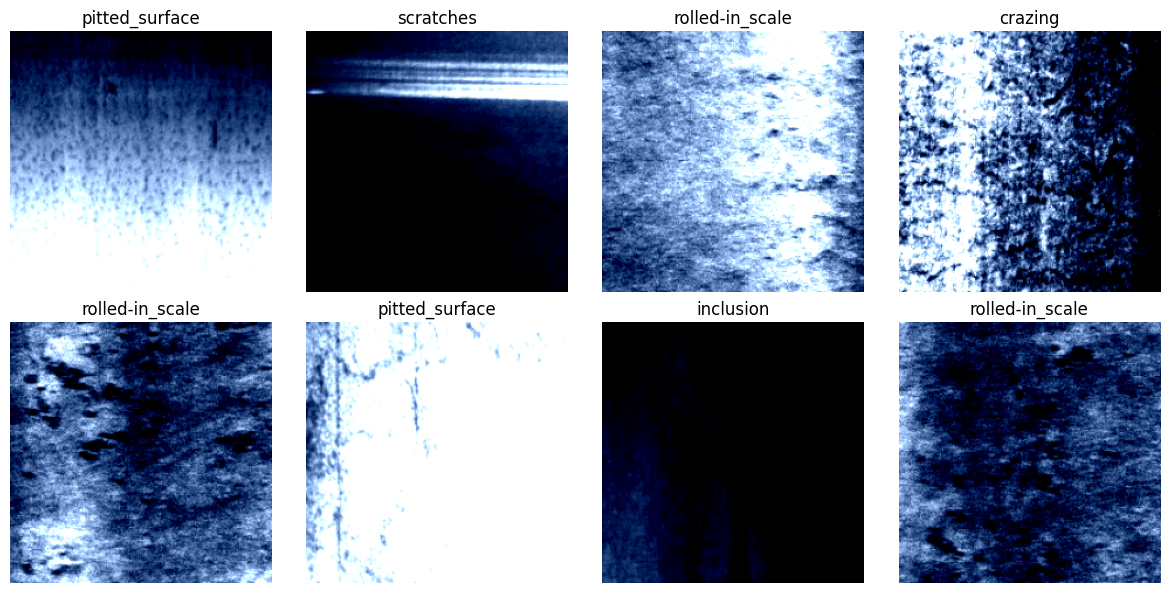

In [8]:
#Matplot lib code - sanity check
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


tmp_loader = DataLoader(train_ds, batch_size = 8, shuffle = True)
imgs, labels = next(iter(tmp_loader))
print(f'batch shape: {imgs.shape}')
print(f'labels: {labels}')


fig, axes = plt.subplots(2, 4, figsize = (12,6))
class_names = train_ds.classes


for i, ax in enumerate(axes.flat):
  img= imgs[i].permute(1,2,0)
  ax.imshow(img, cmap = 'gray')
  ax.set_title(class_names[labels[i].item()])
  ax.axis('off')


plt.tight_layout()
plt.show()


In [9]:
#dataloaders

#random_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split


n_total = len(train_ds)
n_valid = int(0.2*n_total)
n_train = n_total - n_valid

#validatn into test as well to avoid data leakage
gen = torch.Generator().manual_seed(42)
train_split, valid_split = random_split(train_ds, [n_train, n_valid], generator = gen)



In [10]:
train_dl = DataLoader(train_split, batch_size = 16, shuffle = True)
valid_dl = DataLoader(valid_split, batch_size = 16, shuffle = False)
test_dl = DataLoader(test_ds, batch_size = 16, shuffle = False)


In [11]:
from torchvision import models


model = models.resnet18(models.ResNet18_Weights.DEFAULT)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



#freeze
for params in model.parameters():
  params.require_grad = False


features = model.fc.in_features
model.fc = nn.Linear(features, 6)


model = model.to(device)

print(device)
print(model.fc)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


cuda
Linear(in_features=512, out_features=6, bias=True)


In [12]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr = 1e-3)


In [13]:
#train
total_epochs = 5
for epochs in range(total_epochs):
  train_loss = 0.0
  model.train()
  for images, labels in train_dl:
    images, labels = images.to(device), labels.to(device)
    optimizer.zero_grad()
    logits = model(images)
    loss = criterion(logits, labels)
    loss.backward()
    optimizer.step()


    train_loss += loss.item()

  avg_train_loss = train_loss/len(train_dl)



  #validation
  with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    valid_loss = 0.0
    for images, labels in valid_dl:
      images, labels = images.to(device), labels.to(device)
      out = model(images)
      preds = out.argmax(dim = 1)
      correct += (preds == labels).sum().item()
      total += len(labels)

      valid_loss += criterion(out, labels).item()


    avg_valid_loss = valid_loss/ len(valid_dl)
    valid_acc = correct/total

  print(f' epoch: {epochs} average train loss: {avg_train_loss:.4f}')
  print(f' avg valid loss: {avg_valid_loss} average valid acc: {valid_acc:.4f}')








 epoch: 0 average train loss: 0.8167
 avg valid loss: 0.23927712688843408 average valid acc: 0.9826
 epoch: 1 average train loss: 0.2967
 avg valid loss: 0.11829740719662772 average valid acc: 0.9896
 epoch: 2 average train loss: 0.2005
 avg valid loss: 0.08773417729470465 average valid acc: 0.9896
 epoch: 3 average train loss: 0.1550
 avg valid loss: 0.07233734666887257 average valid acc: 0.9896
 epoch: 4 average train loss: 0.1241
 avg valid loss: 0.06547822389337751 average valid acc: 0.9896


In [14]:
#test
from sklearn.metrics import confusion_matrix, classification_report
with torch.no_grad():
  all_preds = []
  all_labels = []
  for images, labels in test_dl:
    images, labels = images.to(device), labels.to(device)
    out = model(images)
    preds = out.argmax(dim = 1)
    all_preds.extend(preds.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())




  print(classification_report(all_labels, all_preds, target_names  = test_ds.classes))


                 precision    recall  f1-score   support

        crazing       1.00      1.00      1.00        60
      inclusion       0.97      0.95      0.96        60
        patches       1.00      1.00      1.00        60
 pitted_surface       1.00      0.97      0.98        60
rolled-in_scale       1.00      1.00      1.00        60
      scratches       0.95      1.00      0.98        60

       accuracy                           0.99       360
      macro avg       0.99      0.99      0.99       360
   weighted avg       0.99      0.99      0.99       360



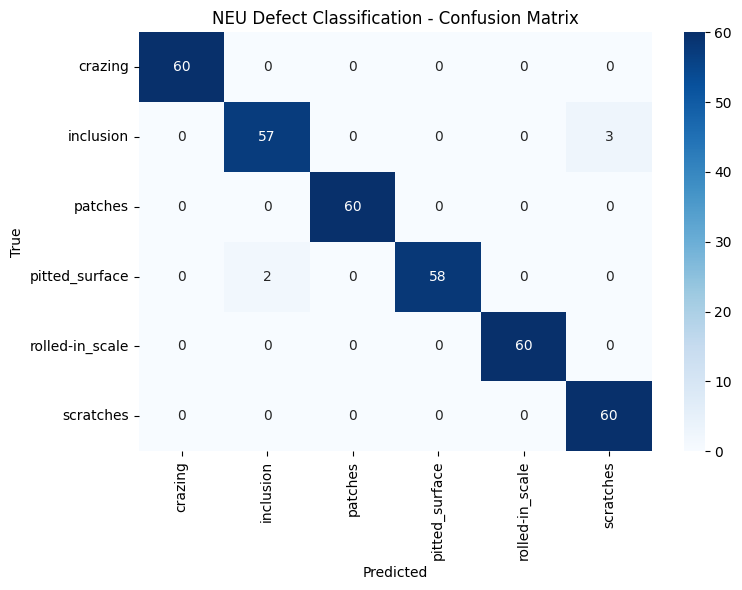

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels= test_ds.classes, yticklabels= test_ds.classes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('NEU Defect Classification - Confusion Matrix')
plt.tight_layout()
plt.show()